# **Child Well-being - POSet analysis**<br/>
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**  

---  
Use the Python Porting of R package `poseticDataAnalysis` by Avellone, De Capitani, Fattore.  
Added some implementations to work with Polars dataframes and handle `null` values ​​as uncertainty intervals in the hyperlattice.

**reference:**  
Fattore M., De Capitani L., Avellone A., Suardi A. (2024).  
*A fuzzy posetic toolbox for multi-criteria evaluation on ordinal data systems.*  
Annals of Operations Research. [doi:10.1007/s10479-024-06352-3](https://link.springer.com/article/10.1007/s10479-024-06352-3?utm_source=researchgate.net&utm_medium=article)

In [1]:
import sys; sys.path.insert(0, "..")
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import poset as P
import pickle
import os

---
## 0. Summary of available functions

| Categoria | Funzioni |
|-----------|----------|
| **Constructors** | `POSet`, `LinearPOSet`, `BinaryVariablePOSet` |
| **Operations** | `ProductPOSet`, `DisjointSumPOSet`, `LinearSumPOSet`, `DualPOSet`, `IntersectionPOSet`, `LiftingPOSet`, `LexicographicProductPOSet`, `CrownPOSet`, `FencePOSet` |
| **Relations** | `IsReflexive`, `IsSymmetric`, `IsAntisymmetric`, `IsTransitive`, `IsPartialOrder`, `IsPreorder`, `TransitiveClosure`, `ReflexiveClosure` |
| **Query** | `POSetElements`, `DominanceMatrix`, `Dominates`, `IsDominatedBy`, `IsComparableWith`, `IsIncomparableWith`, `ComparabilitySetOf`, `IncomparabilitySetOf`, `UpsetOf`, `DownsetOf`, `POSetMaximals`, `POSetMinimals`, `CoverRelation`, `CoverMatrix`, `POSetMeet`, `POSetJoin`, `IsExtensionOf` |
| **Linear extensions** | `LEGenerator`, `LEBubleyDyer`, `LEGet` |
| **MRP** | `ExactMRP`, `BubleyDyerMRPGenerator`, `BubleyDyerMRP`, `LexMRP` |
| **Separation** | `ExactSeparation`, `BuildBubleyDyerSeparationGenerator`, `BubleyDyerSeparation`, `LexSeparation` |
| **Evaluation** | `ExactEvaluation`, `BuildBubleyDyerEvaluationGenerator`, `BubleyDyerEvaluation` |
| **Dominance** | `BLSDominance` |
| **Fuzzy** | `FuzzyInBetweenness`, `FuzzyInBetweennessMinMax`, `FuzzyInBetweennessProbabilistic`, `FuzzySeparation`, `FuzzySeparationMinMax`, `FuzzySeparationProbabilistic` |
| **Embedding** | `BidimentionalPosetRepresentation`, `OptimalBidimensionalEmbedding` |

## 1. Import POSets

In [2]:
n_levels_macro = 3
path = f"../data/050_posets.pkl"
with open(path, "rb") as f:
    results = pickle.load(f)

### 1.1 Select POSet to explore

In [3]:
# Available datasets: ind_2018, ind_2015, exp_2018, exp_2015

result_sel = results['ind_2018'] # select the results for the dataset you want to explore

---
## 1. Mutual Ranking Probabilities (MRP)

In [4]:
# Try the MRP generator for a larger number of iterations to get more stable results.
# Note: this will take a while to run, especially for the possible poset, which is much larger than the certain one.
n = 30_000
seed = 42
gen = P.BubleyDyerMRPGenerator(result_sel['poset_certain'], seed=seed)
mrp_cert = P.BubleyDyerMRP(gen, n=n)
poss = P.BubleyDyerMRPGenerator(result_sel['poset_possible'], seed=seed)
mrp_poss = P.BubleyDyerMRP(poss, n=n)

In [ ]:
# Exact MRP (without sampling) for comparison.
# Note: this will be very fast for the certain poset, 
# but will take a very long time to run for all the possible poset, which is much larger than the certain one.
#mrp_cert = P.ExactMRP(result_sel['poset_certain'])
#mrp_poss = P.ExactMRP(result_sel['poset_possible'])

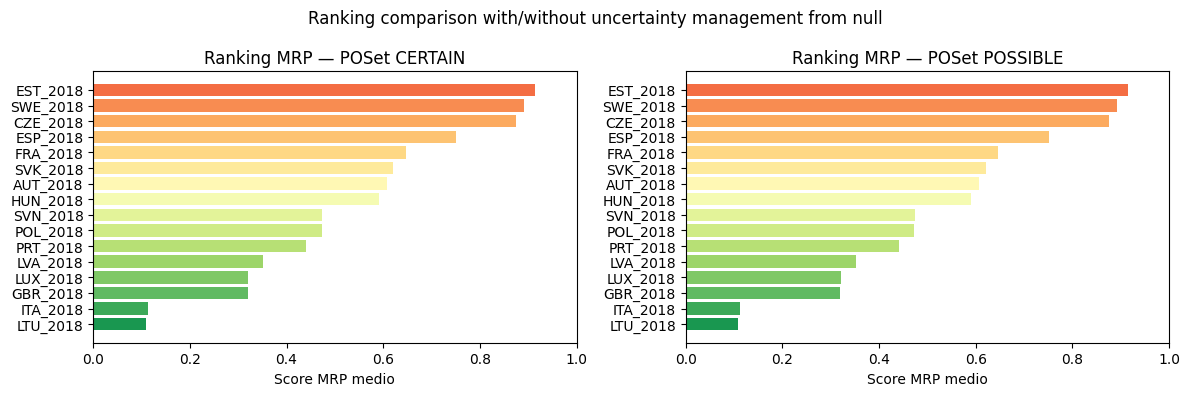

In [5]:
el = result_sel['elements']
score_cert = mrp_cert['MRP'].mean(axis=0)
score_poss = mrp_poss['MRP'].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, title in [
    (axes[0], score_cert, 'Ranking MRP — POSet CERTAIN'),
    (axes[1], score_poss, 'Ranking MRP — POSet POSSIBLE'),
]:
    rank = sorted(zip(el, scores), key=lambda x: -x[1])
    countries = [r[0] for r in rank]
    vals      = [r[1] for r in rank]
    ax.barh(countries[::-1], vals[::-1],
            color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(countries)))[::-1])
    ax.set_xlabel('Score MRP medio')
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.suptitle('Ranking comparison with/without uncertainty management from null', fontsize=12)
plt.tight_layout()
plt.show()

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*